In [12]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.svm import SVR
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import warnings
warnings.filterwarnings('ignore')

print("✅ All Libraries Imported Successfully!")

✅ All Libraries Imported Successfully!


In [13]:
from google.colab import files
uploaded = files.upload()  # CSV upload panna

df = pd.read_csv('kanchipuram_house_prices.csv')
print("✅ Dataset Loaded!")
print(f"Shape: {df.shape}")
df.head(10)

Saving Kanchipuram_House_Price_Prediction.ipynb to Kanchipuram_House_Price_Prediction.ipynb
✅ Dataset Loaded!
Shape: (100, 10)


,id,area_sqft,bedrooms,bathrooms,age_years,location,near_temple,road_type,water_supply,price_inr
0,1,650,1,1,15,Kanchipuram Town,1,Paved,Municipal,1850000
1,2,900,2,1,10,Singaperumal Koil,0,Paved,Borewell,2200000
2,3,1200,3,2,5,Walajabad,0,Unpaved,Municipal,2750000
3,4,1500,3,2,2,Kanchipuram Town,1,Paved,Municipal,4200000
4,5,800,2,1,20,Uthiramerur,0,Unpaved,Borewell,1600000
5,6,1800,4,3,1,Kanchipuram Town,1,Paved,Municipal,5500000
6,7,600,1,1,25,Walajabad,0,Unpaved,Borewell,1100000
7,8,2000,4,3,3,Singaperumal Koil,1,Paved,Municipal,5200000
8,9,1100,3,2,8,Uthiramerur,0,Paved,Borewell,2400000
9,10,1400,3,2,4,Kanchipuram Town,1,Paved,Municipal,3900000


In [14]:
print("=" * 50)
print("📊 DATASET INFO")
print("=" * 50)
print(df.info())

print("\n📈 BASIC STATISTICS")
print(df.describe())

print("\n❓ NULL VALUES")
print(df.isnull().sum())

print("\n📍 LOCATIONS")
print(df['location'].value_counts())

📊 DATASET INFO
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 10 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   id            100 non-null    int64 
 1   area_sqft     100 non-null    int64 
 2   bedrooms      100 non-null    int64 
 3   bathrooms     100 non-null    int64 
 4   age_years     100 non-null    int64 
 5   location      100 non-null    object
 6   near_temple   100 non-null    int64 
 7   road_type     100 non-null    object
 8   water_supply  100 non-null    object
 9   price_inr     100 non-null    int64 
dtypes: int64(7), object(3)
memory usage: 7.9+ KB
None

📈 BASIC STATISTICS
               id    area_sqft    bedrooms   bathrooms   age_years  \
count  100.000000   100.000000  100.000000  100.000000  100.000000   
mean    50.500000  1301.300000    2.880000    2.080000    8.830000   
std     29.011492   520.872723    1.139555    0.939374    7.585279   
min      1.000000   50

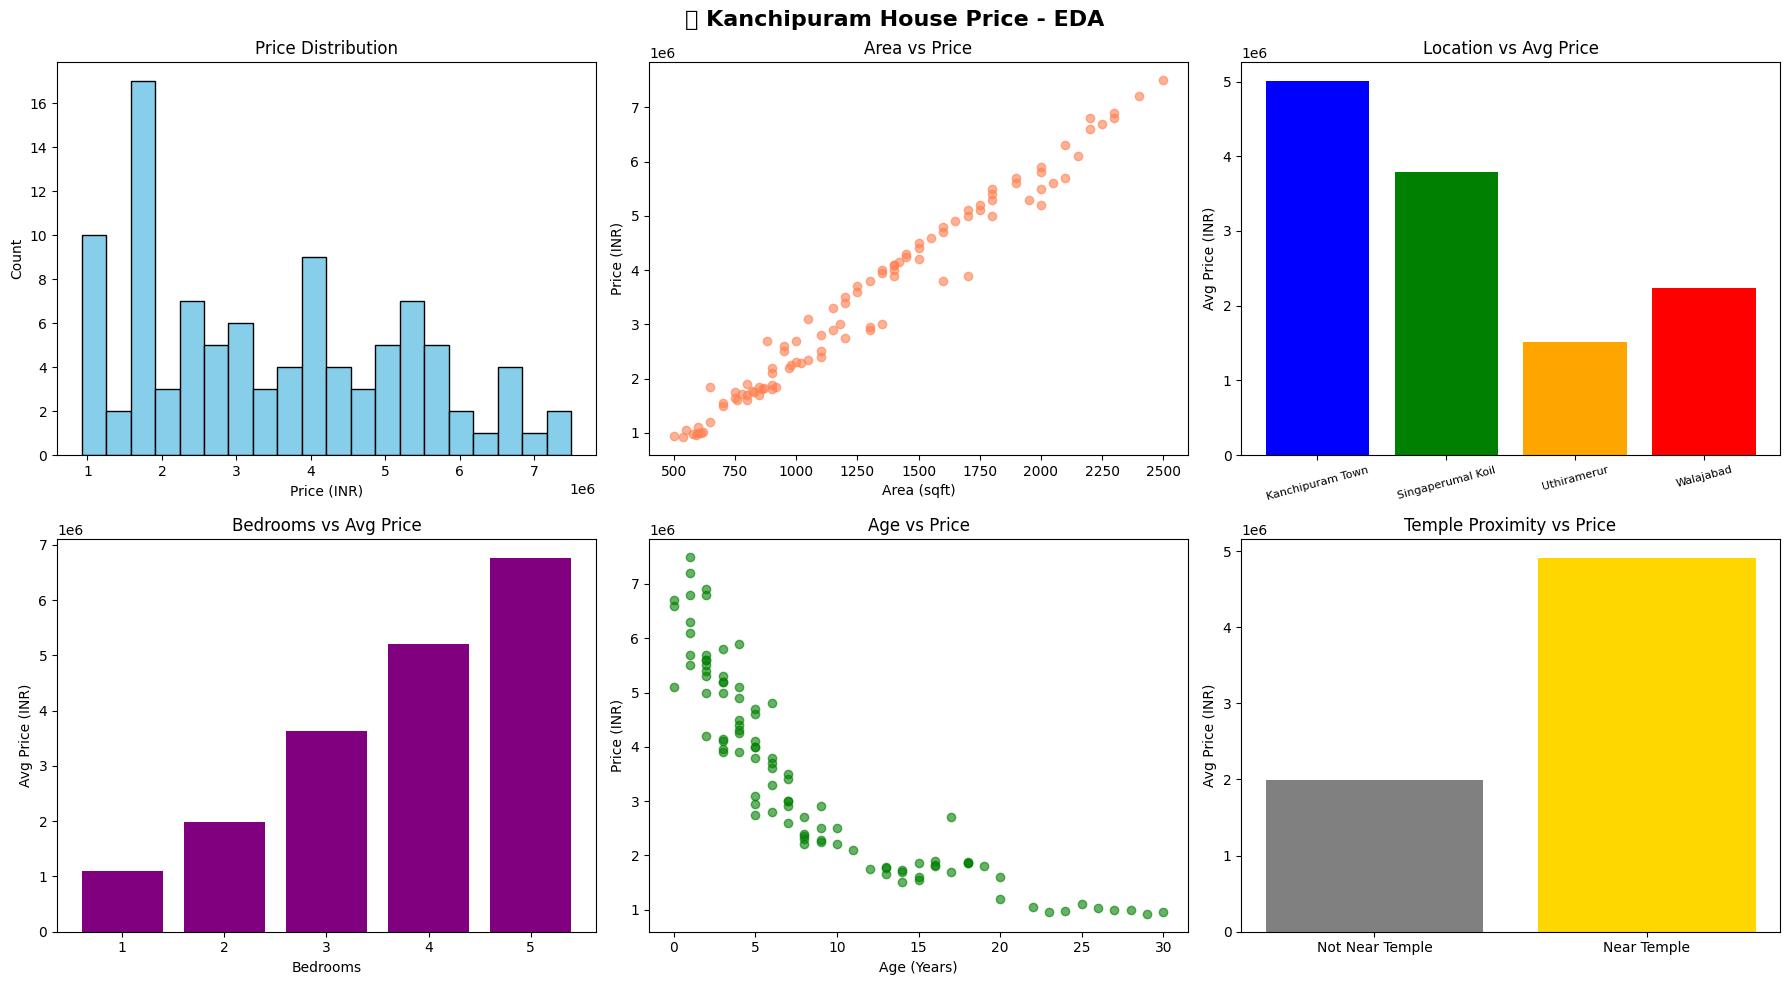

✅ Graphs Done!


In [15]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle('🏠 Kanchipuram House Price - EDA', fontsize=16, fontweight='bold')

# 1. Price Distribution
axes[0,0].hist(df['price_inr'], bins=20, color='skyblue', edgecolor='black')
axes[0,0].set_title('Price Distribution')
axes[0,0].set_xlabel('Price (INR)')
axes[0,0].set_ylabel('Count')

# 2. Area vs Price
axes[0,1].scatter(df['area_sqft'], df['price_inr'], color='coral', alpha=0.6)
axes[0,1].set_title('Area vs Price')
axes[0,1].set_xlabel('Area (sqft)')
axes[0,1].set_ylabel('Price (INR)')

# 3. Location vs Price
location_avg = df.groupby('location')['price_inr'].mean()
axes[0,2].bar(location_avg.index, location_avg.values, color=['blue','green','orange','red'])
axes[0,2].set_title('Location vs Avg Price')
axes[0,2].set_xticklabels(location_avg.index, rotation=15, fontsize=8)
axes[0,2].set_ylabel('Avg Price (INR)')

# 4. Bedrooms vs Price
bedroom_avg = df.groupby('bedrooms')['price_inr'].mean()
axes[1,0].bar(bedroom_avg.index, bedroom_avg.values, color='purple')
axes[1,0].set_title('Bedrooms vs Avg Price')
axes[1,0].set_xlabel('Bedrooms')
axes[1,0].set_ylabel('Avg Price (INR)')

# 5. Age vs Price
axes[1,1].scatter(df['age_years'], df['price_inr'], color='green', alpha=0.6)
axes[1,1].set_title('Age vs Price')
axes[1,1].set_xlabel('Age (Years)')
axes[1,1].set_ylabel('Price (INR)')

# 6. Near Temple vs Price
temple_avg = df.groupby('near_temple')['price_inr'].mean()
axes[1,2].bar(['Not Near Temple', 'Near Temple'], temple_avg.values, color=['gray','gold'])
axes[1,2].set_title('Temple Proximity vs Price')
axes[1,2].set_ylabel('Avg Price (INR)')

plt.tight_layout()
plt.show()
print("✅ Graphs Done!")

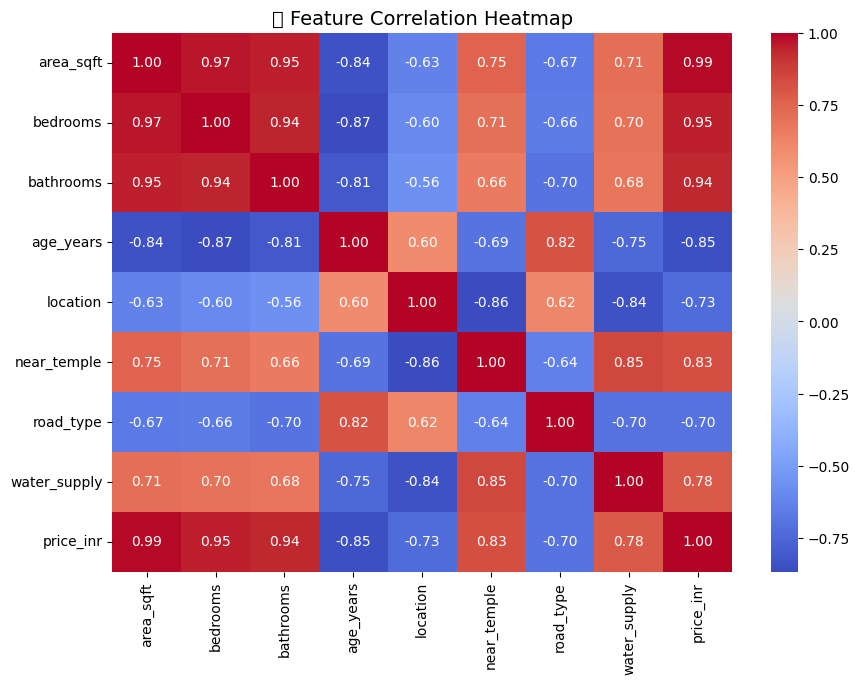

In [16]:
# Encode categorical columns for heatmap
df_heat = df.copy()
le = LabelEncoder()
df_heat['location'] = le.fit_transform(df_heat['location'])
df_heat['road_type'] = le.fit_transform(df_heat['road_type'])
df_heat['water_supply'] = le.fit_transform(df_heat['water_supply'])

plt.figure(figsize=(10, 7))
sns.heatmap(df_heat.drop('id', axis=1).corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('🔥 Feature Correlation Heatmap', fontsize=14)
plt.show()

In [17]:
df_model = df.copy()

# Label Encoding
le = LabelEncoder()
df_model['location'] = le.fit_transform(df_model['location'])
df_model['road_type'] = le.fit_transform(df_model['road_type'])
df_model['water_supply'] = le.fit_transform(df_model['water_supply'])

# Features & Target
X = df_model.drop(['id', 'price_inr'], axis=1)
y = df_model['price_inr']

# Train Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Scaling
scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc = scaler.transform(X_test)

print(f"✅ Train size: {X_train.shape}")
print(f"✅ Test size:  {X_test.shape}")

✅ Train size: (80, 8)
✅ Test size:  (20, 8)


In [18]:
# 6 Models Define panna
models = {
    '1. Linear Regression':        LinearRegression(),
    '2. Ridge Regression':         Ridge(alpha=1.0),
    '3. Decision Tree':            DecisionTreeRegressor(random_state=42),
    '4. Random Forest':            RandomForestRegressor(n_estimators=100, random_state=42),
    '5. Gradient Boosting':        GradientBoostingRegressor(n_estimators=100, random_state=42),
    '6. Support Vector Regression':SVR(kernel='rbf', C=100000, epsilon=50000)
}

results = []

print("=" * 65)
print(f"{'Model':<30} {'MAE':>10} {'RMSE':>12} {'R² Score':>10}")
print("=" * 65)

for name, model in models.items():
    # SVR ku scaled data use panna
    if 'SVR' in name or 'Support' in name:
        model.fit(X_train_sc, y_train)
        y_pred = model.predict(X_test_sc)
    else:
        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)

    mae  = mean_absolute_error(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    r2   = r2_score(y_test, y_pred)

    results.append({
        'Model': name,
        'MAE': mae,
        'RMSE': rmse,
        'R2 Score': r2,
        'Predictions': y_pred
    })

    print(f"{name:<30} ₹{mae:>9,.0f} ₹{rmse:>11,.0f} {r2:>10.4f}")

print("=" * 65)
print("✅ All 6 Models Trained!")

Model                                 MAE         RMSE   R² Score
1. Linear Regression           ₹  119,848 ₹    147,241     0.9904
2. Ridge Regression            ₹  122,605 ₹    146,878     0.9905
3. Decision Tree               ₹  237,500 ₹    398,566     0.9299
4. Random Forest               ₹  173,168 ₹    314,657     0.9563
5. Gradient Boosting           ₹  137,083 ₹    222,118     0.9782
6. Support Vector Regression   ₹  510,315 ₹    659,330     0.8081
✅ All 6 Models Trained!


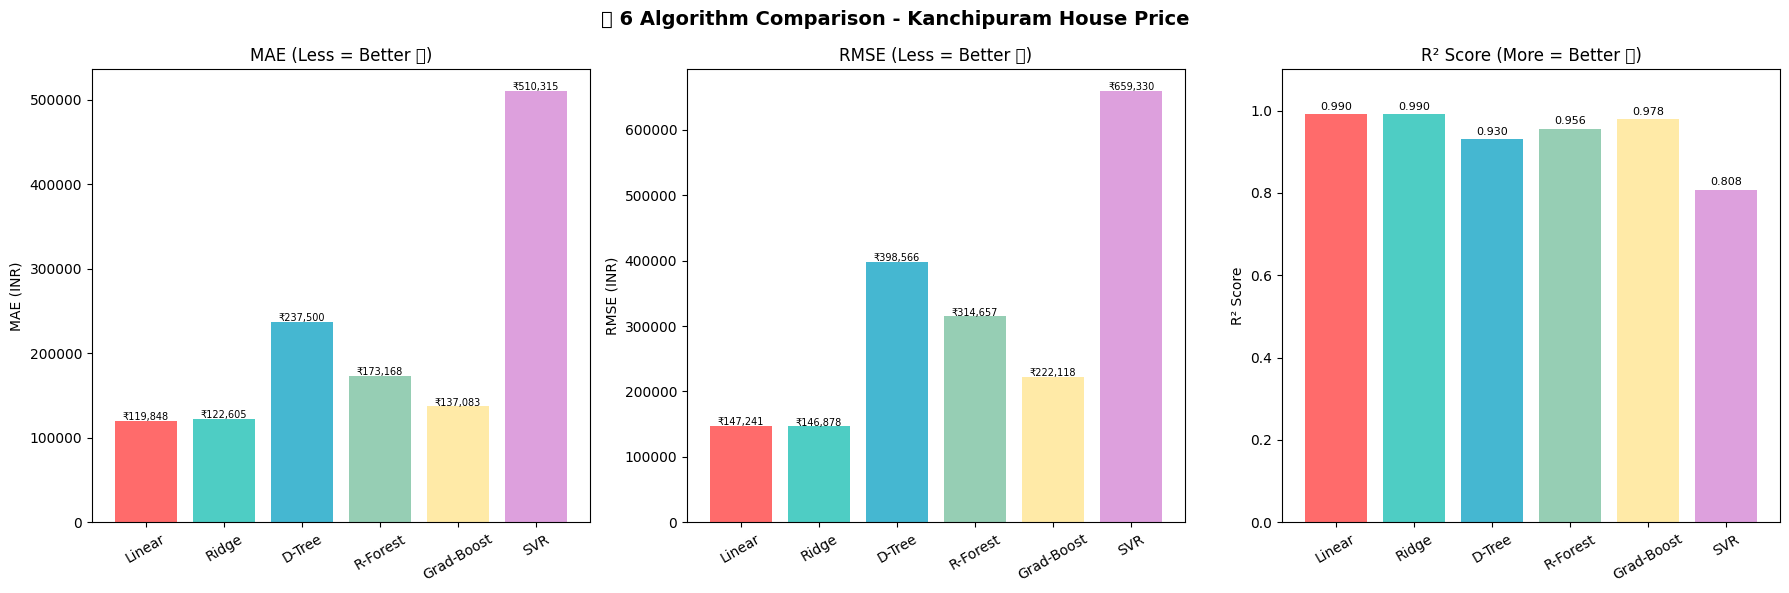

In [19]:
results_df = pd.DataFrame(results)[['Model', 'MAE', 'RMSE', 'R2 Score']]
results_df['Model_Short'] = ['Linear', 'Ridge', 'D-Tree', 'R-Forest', 'Grad-Boost', 'SVR']

fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.suptitle('📊 6 Algorithm Comparison - Kanchipuram House Price', fontsize=14, fontweight='bold')

colors = ['#FF6B6B','#4ECDC4','#45B7D1','#96CEB4','#FFEAA7','#DDA0DD']

# MAE Comparison
axes[0].bar(results_df['Model_Short'], results_df['MAE'], color=colors)
axes[0].set_title('MAE (Less = Better ✅)')
axes[0].set_ylabel('MAE (INR)')
axes[0].tick_params(axis='x', rotation=30)
for i, v in enumerate(results_df['MAE']):
    axes[0].text(i, v + 1000, f'₹{v:,.0f}', ha='center', fontsize=7)

# RMSE Comparison
axes[1].bar(results_df['Model_Short'], results_df['RMSE'], color=colors)
axes[1].set_title('RMSE (Less = Better ✅)')
axes[1].set_ylabel('RMSE (INR)')
axes[1].tick_params(axis='x', rotation=30)
for i, v in enumerate(results_df['RMSE']):
    axes[1].text(i, v + 1000, f'₹{v:,.0f}', ha='center', fontsize=7)

# R2 Score Comparison
axes[2].bar(results_df['Model_Short'], results_df['R2 Score'], color=colors)
axes[2].set_title('R² Score (More = Better ✅)')
axes[2].set_ylabel('R² Score')
axes[2].tick_params(axis='x', rotation=30)
axes[2].set_ylim(0, 1.1)
for i, v in enumerate(results_df['R2 Score']):
    axes[2].text(i, v + 0.01, f'{v:.3f}', ha='center', fontsize=8)

plt.tight_layout()
plt.show()

🏆 BEST MODEL RESULT
🥇 Model     : 2. Ridge Regression
📈 R² Score  : 0.9905 (99.0% accurate)
💰 Avg Error : ₹122,605


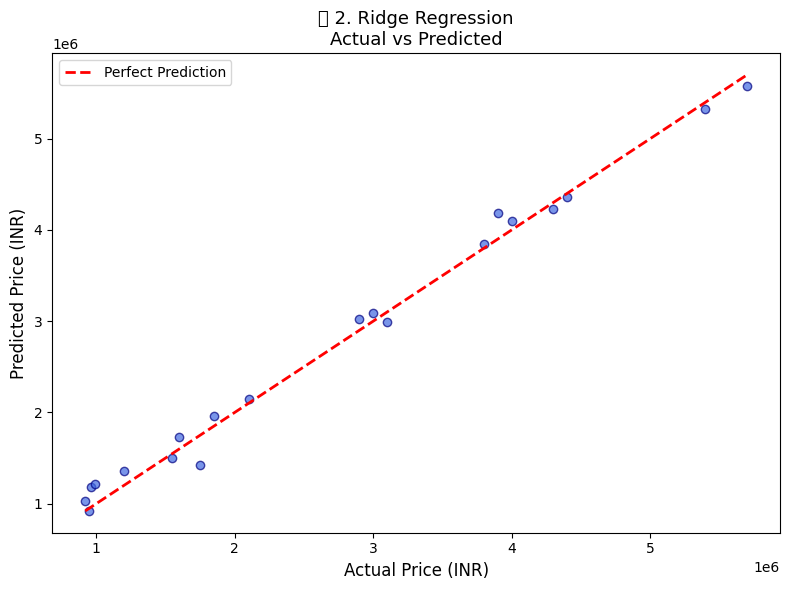

In [20]:
best_idx = results_df['R2 Score'].idxmax()
best_model_name = results_df.loc[best_idx, 'Model']
best_r2 = results_df.loc[best_idx, 'R2 Score']
best_mae = results_df.loc[best_idx, 'MAE']

print("=" * 50)
print("🏆 BEST MODEL RESULT")
print("=" * 50)
print(f"🥇 Model     : {best_model_name}")
print(f"📈 R² Score  : {best_r2:.4f} ({best_r2*100:.1f}% accurate)")
print(f"💰 Avg Error : ₹{best_mae:,.0f}")
print("=" * 50)

# Actual vs Predicted Plot for Best Model
best_pred = results[best_idx]['Predictions']

plt.figure(figsize=(8, 6))
plt.scatter(y_test, best_pred, color='royalblue', alpha=0.7, edgecolors='navy')
plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()], 'r--', linewidth=2, label='Perfect Prediction')
plt.xlabel('Actual Price (INR)', fontsize=12)
plt.ylabel('Predicted Price (INR)', fontsize=12)
plt.title(f'🏆 {best_model_name}\nActual vs Predicted', fontsize=13)
plt.legend()
plt.tight_layout()
plt.show()

In [21]:
print("🏠 KANCHIPURAM HOUSE PRICE PREDICTOR")
print("=" * 45)

# Ungal veedu details enter panna
new_house = pd.DataFrame({
    'area_sqft':   [1200],
    'bedrooms':    [3],
    'bathrooms':   [2],
    'age_years':   [5],
    'location':    [2],    # 0=Kanchipuram Town, 1=Singaperumal Koil, 2=Uthiramerur, 3=Walajabad
    'near_temple': [1],    # 1=Yes, 0=No
    'road_type':   [1],    # 1=Paved, 0=Unpaved
    'water_supply':[1],    # 1=Municipal, 0=Borewell
})

# Best model use panna predict ku
best_model = list(models.values())[best_idx]

if best_idx == 5:  # SVR
    new_house_sc = scaler.transform(new_house)
    predicted = best_model.predict(new_house_sc)[0]
else:
    predicted = best_model.predict(new_house)[0]

print(f"\n📐 Area        : 1200 sqft")
print(f"🛏️  Bedrooms    : 3")
print(f"🚿 Bathrooms   : 2")
print(f"📅 Age         : 5 years")
print(f"📍 Location    : Uthiramerur")
print(f"🛕 Near Temple : Yes")
print(f"🛣️  Road        : Paved")
print(f"💧 Water       : Municipal")
print(f"\n💰 Predicted Price : ₹{predicted:,.0f}")
print(f"   (approx ₹{predicted/100000:.1f} Lakhs)")
print("=" * 45)

🏠 KANCHIPURAM HOUSE PRICE PREDICTOR

📐 Area        : 1200 sqft
🛏️  Bedrooms    : 3
🚿 Bathrooms   : 2
📅 Age         : 5 years
📍 Location    : Uthiramerur
🛕 Near Temple : Yes
🛣️  Road        : Paved
💧 Water       : Municipal

💰 Predicted Price : ₹3,231,941
   (approx ₹32.3 Lakhs)
